# E-Commerce Sales Performance Analytics
**Dataset:** UCI E-Commerce Orders Dataset (~541K transactions)  
**Goal:** Clean raw data, engineer features, explore patterns, and export a Power BI-ready CSV.

## 1. Imports & Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings("ignore")
%matplotlib inline

RAW_PATH   = "../data/raw/raw_ecommerce.csv"
CLEAN_PATH = "../data/cleaned/clean_ecommerce.csv"

os.makedirs("../data", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

## 2. Load Raw Data
The dataset uses **ISO-8859-1** encoding, product descriptions contain 
special characters that break the default UTF-8 reader.

In [10]:
df_raw = pd.read_csv(RAW_PATH, encoding="ISO-8859-1")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Load Raw Data

The dataset loaded successfully with 541,909 rows and 8 columns, confirming the full transaction history is intact and ready for inspection.

In [11]:
df_raw.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

 Data Types

InvoiceDate is stored as a plain string and CustomerID as a float. Both need fixing before analysis. Everything else is in a usable format.

## 3. Data Quality Audit
Before cleaning anything, we document every problem in the raw data.

In [12]:
print("=== DATA QUALITY AUDIT ===\n")
print(f"Duplicate rows     : {df_raw.duplicated().sum():,}")
print(f"Missing CustomerID : {df_raw['CustomerID'].isnull().sum():,}")
print(f"Missing Description: {df_raw['Description'].isnull().sum():,}")
print(f"Cancellations (C.) : {df_raw['InvoiceNo'].astype(str).str.startswith('C').sum():,}")
print(f"Qty <= 0           : {(df_raw['Quantity'] <= 0).sum():,}")
print(f"UnitPrice <= 0     : {(df_raw['UnitPrice'] <= 0).sum():,}")
print(f"\nDate range: {df_raw['InvoiceDate'].min()}  →  {df_raw['InvoiceDate'].max()}")
print(f"Countries : {df_raw['Country'].nunique()} unique")

=== DATA QUALITY AUDIT ===

Duplicate rows     : 5,268
Missing CustomerID : 135,080
Missing Description: 1,454
Cancellations (C.) : 9,288
Qty <= 0           : 10,624
UnitPrice <= 0     : 2,517

Date range: 1/10/2011 10:04  →  9/9/2011 9:52
Countries : 38 unique


 Data Quality Audit

The data has significant quality issues. 135,080 rows have no CustomerID, 9,288 are cancellations, and over 10,000 have invalid quantities. These all need to be removed before any analysis can be trusted.

## 4. Data Cleaning

| Step | What it removes |
|---|---|
| Drop duplicates | Fully identical rows |
| Drop missing CustomerID / Description | Rows we can't link to a customer or product |
| Remove cancellations | InvoiceNo starting with 'C' |
| Remove Quantity ≤ 0 | Returns and data errors |
| Remove UnitPrice ≤ 0 | Free or erroneous entries |
| Parse InvoiceDate | Converts string → datetime |

In [13]:
df = df_raw.copy()

df.drop_duplicates(inplace=True)
df.dropna(subset=["CustomerID", "Description"], inplace=True)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(f"Before : {df_raw.shape[0]:,} rows")
print(f"After  : {df.shape[0]:,} rows")
print(f"Removed: {df_raw.shape[0] - df.shape[0]:,} rows ({(1 - df.shape[0]/df_raw.shape[0])*100:.1f}%)")

Before : 541,909 rows
After  : 392,692 rows
Removed: 149,217 rows (27.5%)


Data Cleaning

After applying all cleaning steps, 149,217 rows (27.5%) were removed, leaving 392,692 clean, reliable rows to work with.

In [14]:
# Confirm no remaining nulls in key columns
df[["InvoiceNo","CustomerID","Description","Quantity","UnitPrice"]].isnull().sum()

InvoiceNo      0
CustomerID     0
Description    0
Quantity       0
UnitPrice      0
dtype: int64

Null Check

All key columns return zero nulls, confirming the cleaned dataset is complete and has no missing values that could skew results.

## 5. Feature Engineering
The raw data has no revenue column and no usable date parts.  
We derive everything Power BI needs here so the CSV is immediately usable.

| New column | Logic |
|---|---|
| `Revenue` | `Quantity × UnitPrice` |
| `Year` | Extracted from InvoiceDate |
| `Month` | Integer month (1–12) |
| `MonthName` | Jan, Feb … Dec |
| `YearMonth` | e.g. `2011-03` used as the time axis in Power BI |
| `DayOfWeek` | Monday … Sunday |

In [15]:
df["Revenue"]   = df["Quantity"] * df["UnitPrice"]
df["Year"]      = df["InvoiceDate"].dt.year
df["Month"]     = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.strftime("%b")
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

df[["InvoiceDate","Revenue","Year","Month","MonthName","YearMonth","DayOfWeek"]].head()

,InvoiceDate,Revenue,Year,Month,MonthName,YearMonth,DayOfWeek
0,2010-12-01 08:26:00,15.30,2010,12,Dec,2010-12,Wednesday
1,2010-12-01 08:26:00,20.34,2010,12,Dec,2010-12,Wednesday
2,2010-12-01 08:26:00,22.00,2010,12,Dec,2010-12,Wednesday
3,2010-12-01 08:26:00,20.34,2010,12,Dec,2010-12,Wednesday
4,2010-12-01 08:26:00,20.34,2010,12,Dec,2010-12,Wednesday


Feature Engineering

Six new columns were successfully derived. Revenue gives us a value metric for every transaction, and the date columns (Year, Month, MonthName, YearMonth, DayOfWeek) give Power BI the time dimensions it needs to build trend visuals.

## 6. Key Performance Indicators

In [16]:
print("=== KEY PERFORMANCE INDICATORS ===\n")
print(f"Total Revenue    : £{df['Revenue'].sum():,.2f}")
print(f"Total Orders     : {df['InvoiceNo'].nunique():,}")
print(f"Unique Customers : {df['CustomerID'].nunique():,}")
print(f"Unique Products  : {df['Description'].nunique():,}")
print(f"Avg Order Value  : £{df.groupby('InvoiceNo')['Revenue'].sum().mean():,.2f}")

=== KEY PERFORMANCE INDICATORS ===

Total Revenue    : £8,887,208.89
Total Orders     : 18,532
Unique Customers : 4,338
Unique Products  : 3,877
Avg Order Value  : £479.56


KPIs

The business generated £8.88M in total revenue from 18,532 orders across 4,338 customers. The average order value of £479 suggests bulk or wholesale purchasing behaviour rather than typical retail.

## 7. Revenue Trend: Monthly

In [17]:
monthly = (
    df.groupby("YearMonth")
    .agg(Revenue=("Revenue","sum"), Orders=("InvoiceNo","nunique"))
    .reset_index()
)
monthly

,YearMonth,Revenue,Orders
0,2010-12,570422.730,1400
1,2011-01,568101.310,987
2,2011-02,446084.920,997
3,2011-03,594081.760,1321
4,2011-04,468374.331,1149
5,2011-05,677355.150,1555
6,2011-06,660046.050,1393
7,2011-07,598962.901,1331
8,2011-08,644051.040,1280
9,2011-09,950690.202,1755


Monthly Revenue Table

Revenue is lowest in February (£446K) and peaks in November (£1.15M), clearly showing the business follows a seasonal pattern with Q4 as its strongest period.

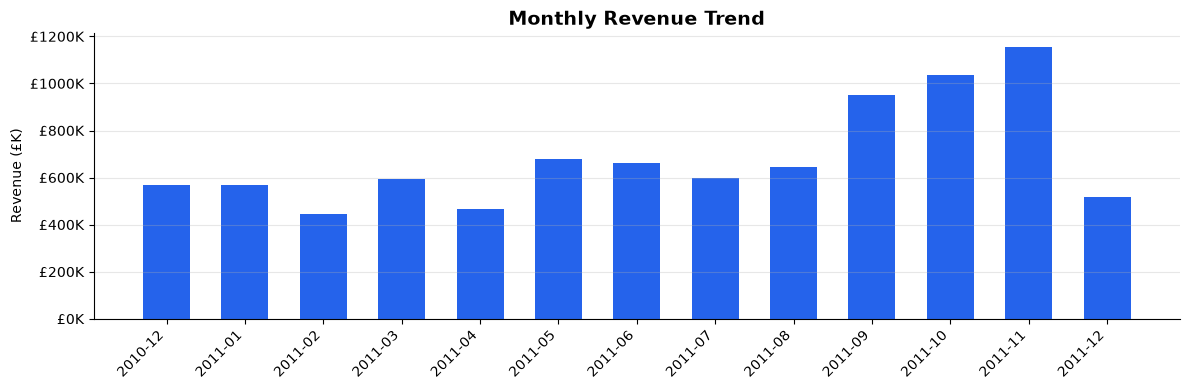

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly["YearMonth"], monthly["Revenue"] / 1000, color="#2563EB", width=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:.0f}K"))
ax.set_xticklabels(monthly["YearMonth"], rotation=45, ha="right")
ax.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (£K)")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

Monthly Revenue Trend

Revenue was relatively stable from January to August 2011 (£446K–£677K), then surged sharply from September onward, peaking in November at £1.15M. This confirms a strong Q4 seasonality pattern driven by holiday shopping, the business generates over a third of its annual revenue in just three months.

## 8. Top 10 Products by Revenue

In [19]:
top_prod = (
    df.groupby("Description")
    .agg(Revenue=("Revenue","sum"), Quantity=("Quantity","sum"))
    .sort_values("Revenue", ascending=False)
    .head(10)
    .reset_index()
)
top_prod

,Description,Revenue,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
1,REGENCY CAKESTAND 3 TIER,142264.75,12374
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706
3,JUMBO BAG RED RETROSPOT,85040.54,46078
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
5,POSTAGE,77803.96,3120
6,PARTY BUNTING,68785.23,15279
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263
8,Manual,53419.93,6933
9,RABBIT NIGHT LIGHT,51251.24,27153


Top 10 Products Table

PAPER CRAFT LITTLE BIRDIE and REGENCY CAKESTAND 3 TIER are the top two revenue drivers, together generating over £310K. The top 10 products span gifts, homewares, and decorative items which are consistent with a novelty retail business.

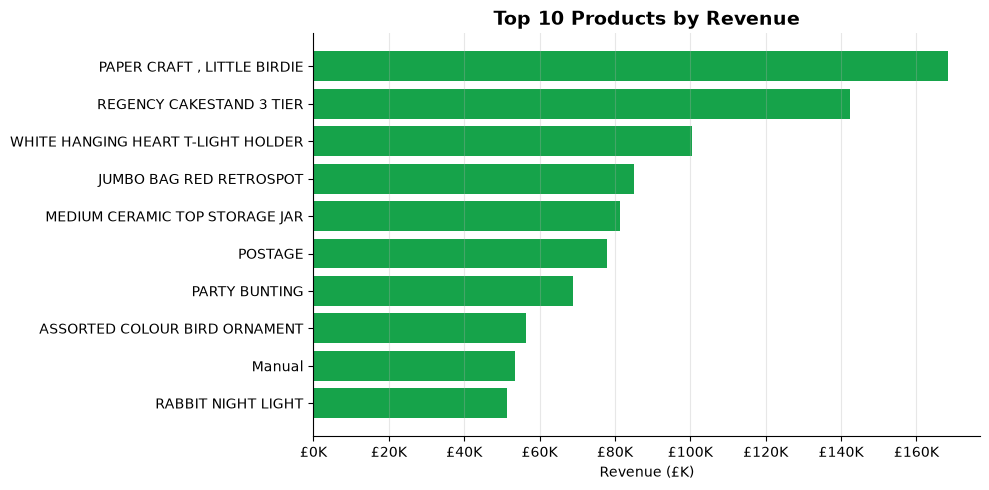

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
data = top_prod.sort_values("Revenue")
ax.barh(data["Description"].str[:35], data["Revenue"] / 1000, color="#16A34A")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:.0f}K"))
ax.set_title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (£K)")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/top_products.png", dpi=150, bbox_inches="tight")
plt.show()

Top 10 Products by Revenue

PAPER CRAFT LITTLE BIRDIE leads at £168K, followed by REGENCY CAKESTAND 3 TIER at £142K. Notably, the top 2 products alone account for nearly £310K around 3.5% of total annual revenue. These are high-volume, high-value hero SKUs that the business cannot afford to run out of stock on.

## 9. Revenue by Country (excluding UK)
The UK accounts for ~91% of all orders, so we isolate 
international markets separately to see their actual contribution.

In [21]:
top_countries = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")
    .agg(Revenue=("Revenue","sum"))
    .sort_values("Revenue", ascending=False)
    .head(10)
    .reset_index()
)
top_countries

,Country,Revenue
0,Netherlands,285446.34
1,EIRE,265262.46
2,Germany,228678.40
3,France,208934.31
4,Australia,138453.81
5,Spain,61558.56
6,Switzerland,56443.95
7,Belgium,41196.34
8,Sweden,38367.83
9,Japan,37416.37


Top Countries Table

Netherlands leads international revenue at £285K, followed by EIRE and Germany. The top 4 markets alone account for nearly £1M, showing real international demand that is currently underdeveloped relative to the UK.

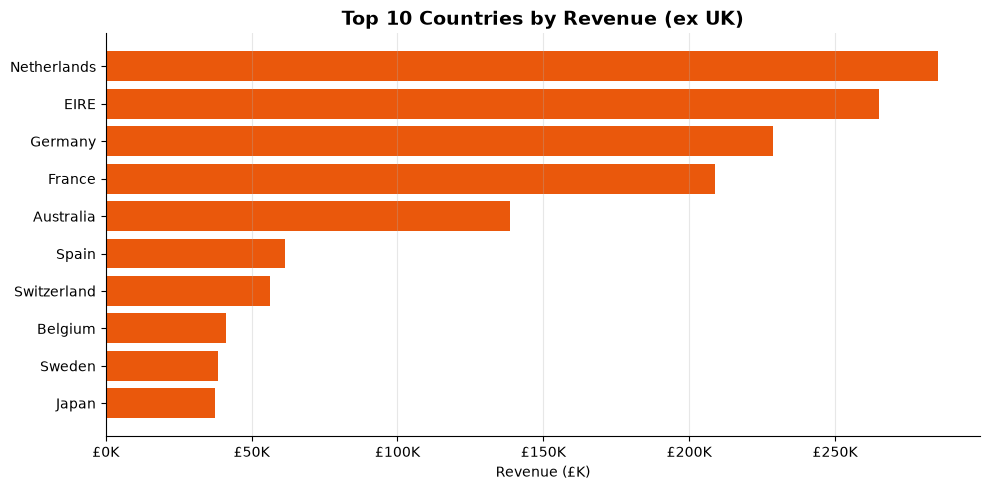

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
data = top_countries.sort_values("Revenue")
ax.barh(data["Country"], data["Revenue"] / 1000, color="#EA580C")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:.0f}K"))
ax.set_title("Top 10 Countries by Revenue (ex UK)", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (£K)")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/top_countries.png", dpi=150, bbox_inches="tight")
plt.show()

 Top Countries Table

Netherlands leads international revenue at £285K, followed by EIRE and Germany. The top 4 markets alone account for nearly £1M, showing real international demand that is currently underdeveloped relative to the UK.

## 10. Revenue by Day of Week

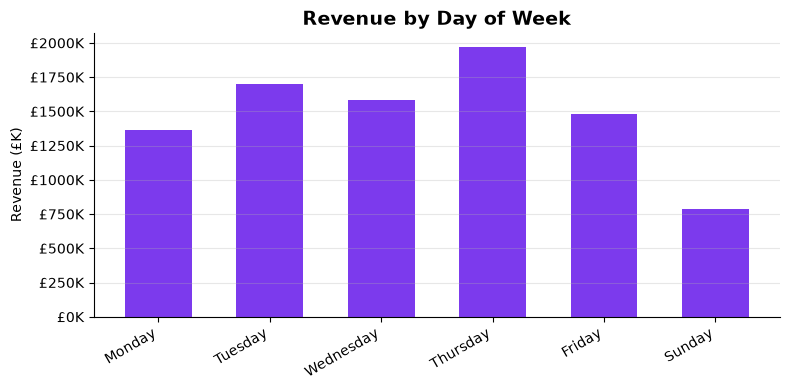

In [23]:
dow = (
    df.groupby("DayOfWeek")["Revenue"]
    .sum()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Sunday"])
    .dropna()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow["DayOfWeek"], dow["Revenue"] / 1000, color="#7C3AED", width=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:.0f}K"))
ax.set_title("Revenue by Day of Week", fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (£K)")
ax.set_xticklabels(dow["DayOfWeek"], rotation=30, ha="right")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/day_of_week.png", dpi=150, bbox_inches="tight")
plt.show()

Day of Week Chart

Thursday generates the most revenue while Sunday is the weakest day. The mid-week concentration points to a trade or B2B customer base that orders during business hours.

## 11. Export Clean CSV for Power BI

In [24]:
df.to_csv(CLEAN_PATH, index=False)
print(f"✓ Saved → {CLEAN_PATH}")
print(f"  Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Columns: {df.columns.tolist()}")

✓ Saved → ../data/cleaned/clean_ecommerce.csv
  Shape  : 392,692 rows × 14 columns
  Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'MonthName', 'YearMonth', 'DayOfWeek']


Export

The cleaned dataset was saved successfully with 392,692 rows and 14 columns, all original fields plus the 6 engineered columns, ready to be imported directly into Power BI.

## Phase 1 Complete

| Step | Status |
|---|---|
| Raw data loaded | ✓ |
| Data quality audit | ✓ |
| Data cleaned | ✓ |
| Features engineered | ✓ |
| EDA charts generated | ✓ |
| `clean_ecommerce.csv` exported | ✓ |

**Next → Power BI:** Import `clean_ecommerce.csv` and build the dashboard.